# 6. 변동성 입력 연구 — 내재변동성(IV) vs 역사변동성(HV), 만기매칭, 프라이싱 검증

발행시점 MC 시뮬레이션의 **변동성 입력**을 정리한다. 기초자산이 지수인 경우 ATM 내재변동성(IV)을,
그 외/자료없음은 역사변동성(HV180)을 쓸 때 — IV 를 어떻게 처리해야 위험이 제대로 반영되고 공정가(fair) 오차가 줄어드는가.

- **자기완결**: `raw/iv_daily_atm`(ATM IV)·`data/cache/px_*`(수익률)·`data/cache/volidx/*`(vol 지수) 읽기만. `module.*` 임포트 없음.
- **구성**: A) IV vs HV 편차, B) base tenor + 평균회귀 → 만기매칭 vol, C) MC 오차검증(HV vs spot-IV vs term-IV), D) VIX-방법론 vol 지수 확보·검증, E) 결론.
- **결론 미리보기**: ATM spot 대체는 잡음만 늘리지만(MAE↑), **만기매칭 IV(≈위험중립 장기평균)** 는 HV 대비 공정가 오차를 줄인다(MAE −17.5%). 스펙의 VIX-방법론(Jiang-Tian)은 vol 지수 미확보(VKOSPI 등)로 북 전체 구현 불가.

In [1]:
import glob, io, urllib.request, warnings
from datetime import date
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
plt.rcParams.update({"savefig.dpi": 400, "savefig.transparent": True, "savefig.bbox": "tight",
                     "figure.figsize": (13.333, 4.6), "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 12, "axes.titleweight": "bold"})
ROOT = Path.cwd(); assert (ROOT / "data").exists(), f"repo 루트에서 실행 (cwd={ROOT})"
DATA, CACHE, RAW, IMG = ROOT / "data", ROOT / "data/cache", ROOT / "data/raw", ROOT / "result/image"
STAT = ROOT / "result/statistics"; IMG.mkdir(parents=True, exist_ok=True)
FACE, DTY = 10000, 1 / 252
C_HV, C_IV, C_TERM, C_ZERO = "#e07a5f", "#5aa9dd", "#1c4a5f", "#c0392b"
IVMAP = {"^KS200": ".KS200", "^GSPC": ".SPX", "^HSCE": ".HSCE", "^HSI": ".HSI",
         "^N225": ".N225", "^NDX": ".NDX", "^GDAXI": ".GDAXI", "^STOXX50E": ".STOXX50"}
def _safe(t): return "px_" + t.replace("^", "_").replace(".", "_") + ".parquet"
print("setup OK | 지수", len(IVMAP))

setup OK | 지수 8


## 데이터 로딩 — 상품·수익률(HV)·ATM IV·vol 지수

In [2]:
df = pd.read_parquet(DATA / "els3_dataset.parquet").sort_values("isu_ord").reset_index(drop=True)
udls = pd.unique(df[["udl1", "udl2", "udl3"]].values.ravel())
RET = {}
for t in udls:
    f = CACHE / _safe(t)
    if f.exists():
        s = pd.read_parquet(f)["close"].dropna(); s = s[~s.index.duplicated()]
        lr = np.log(s).diff().dropna(); RET[t] = (lr.index.values.astype("datetime64[D]"), lr.values.astype(float))
big = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(str(RAW / "iv_daily_atm/iv_daily_atm/*.csv")))], ignore_index=True)
big["calc_date"] = pd.to_datetime(big["calc_date"]); _n0 = len(big); big = big[big.iv.between(0.01, 1.5)]
SER = {ric: g.set_index("calc_date")["iv"].sort_index()[~g.set_index("calc_date").index.duplicated(keep="last")]
       for ric, g in big.groupby("notion_ric")}
IVN = {ric: (s.index.values.astype("datetime64[D]"), s.values.astype(float)) for ric, s in SER.items()}
def volidx(name):
    f = CACHE / "volidx" / f"{name}.parquet"; return pd.read_parquet(f)["v"] if f.exists() else None
print(f"상품 {len(df):,} | 수익률 {len(RET)}종 | ATM IV RIC {len(SER)} (이상치 {_n0-len(big):,}행 제거) | vol지수 {len(list((CACHE/'volidx').glob('*.parquet')))}개")

def hv180(t, dt64):
    if t not in RET: return np.nan
    d, v = RET[t]; i = int(np.searchsorted(d, dt64, "left")); w = v[max(0, i - 180):i]
    return float(w.std(ddof=1) * np.sqrt(252)) if len(w) >= 60 else np.nan
def ivspot(t, dt64):
    ric = IVMAP.get(t)
    if ric is None or ric not in IVN: return np.nan
    d, v = IVN[ric]; i = int(np.searchsorted(d, dt64, "right")); return float(v[i - 1]) if i > 0 else np.nan

상품 58,790 | 수익률 44종 | ATM IV RIC 123 (이상치 986행 제거) | vol지수 9개


---
## A. 내재변동성(IV) vs 역사변동성(HV) — 변동성 자체 비교

각 상품의 기초자산에 대해 발행일 ATM IV 와 HV180 이 얼마나 다른가(부호 있는 편차 중심).

In [3]:
rows = []
for r in df.itertuples(index=False):
    o = int(r.isu_ord); dt64 = np.datetime64(date.fromordinal(o)); yr = date.fromordinal(o).year
    for t in (r.udl1, r.udl2, r.udl3):
        rows.append((r.item, yr, t, hv180(t, dt64), ivspot(t, dt64)))
L = pd.DataFrame(rows, columns=["item", "year", "ticker", "hv", "iv"])
U = L[L.hv.notna() & L.iv.notna()].copy(); U["dev"] = U.iv - U.hv
print(f"[IV vs HV 자산단위 n={len(U):,}]  HV {U.hv.mean()*100:.2f}%  IV {U.iv.mean()*100:.2f}%")
print(f"  부호편차 IV-HV 평균 {U.dev.mean()*100:+.2f}pp 중앙 {U.dev.median()*100:+.2f}pp std {U.dev.std()*100:.2f}pp | "
      f"|편차| {U.dev.abs().mean()*100:.2f}pp | IV>HV {(U.dev>0).mean()*100:.1f}% | corr {np.corrcoef(U.hv,U.iv)[0,1]:.3f}")

[IV vs HV 자산단위 n=146,480]  HV 18.12%  IV 18.02%
  부호편차 IV-HV 평균 -0.09pp 중앙 -0.92pp std 7.75pp | |편차| 4.74pp | IV>HV 42.0% | corr 0.526


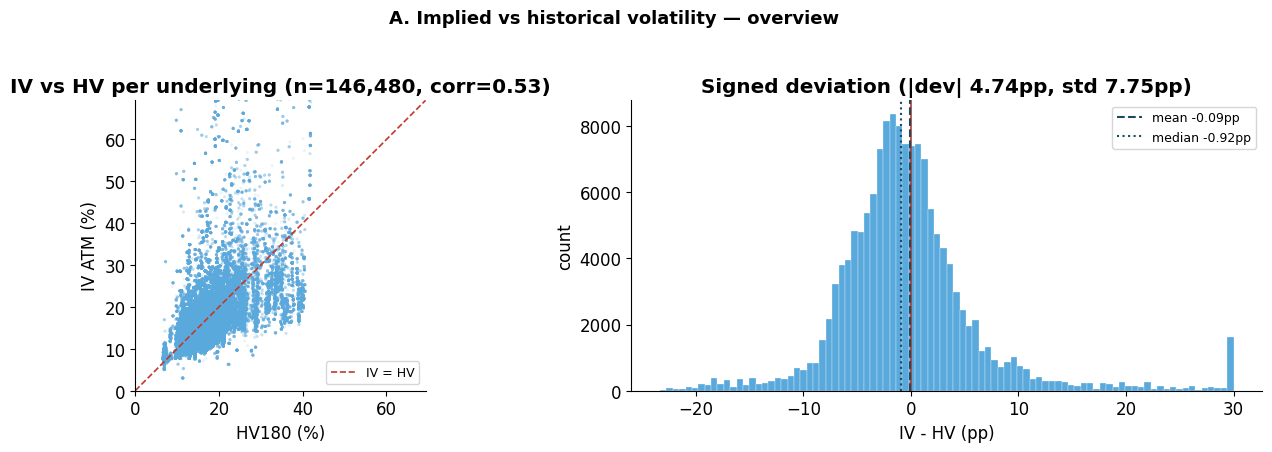

In [4]:
# 그림 A1: 산점 + 부호편차 분포
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))
lim = [0, max(U.hv.quantile(.995), U.iv.quantile(.995)) * 100]
ax[0].scatter(U.hv * 100, U.iv * 100, s=5, alpha=.12, color=C_IV, edgecolors="none")
ax[0].plot(lim, lim, "--", color=C_ZERO, lw=1.2, label="IV = HV")
ax[0].set_xlim(lim); ax[0].set_ylim(lim); ax[0].set_aspect("equal")
ax[0].set_xlabel("HV180 (%)"); ax[0].set_ylabel("IV ATM (%)")
ax[0].set_title(f"IV vs HV per underlying (n={len(U):,}, corr={np.corrcoef(U.hv,U.iv)[0,1]:.2f})"); ax[0].legend(fontsize=9)
d = U.dev * 100
ax[1].hist(d.clip(-30, 30), bins=90, color=C_IV, edgecolor="white", lw=.2)
ax[1].axvline(0, color=C_ZERO, lw=1.2); ax[1].axvline(d.mean(), color=C_TERM, lw=1.5, ls="--", label=f"mean {d.mean():+.2f}pp")
ax[1].axvline(d.median(), color=C_TERM, lw=1.5, ls=":", label=f"median {d.median():+.2f}pp")
ax[1].set_xlabel("IV - HV (pp)"); ax[1].set_ylabel("count"); ax[1].set_title(f"Signed deviation (|dev| {d.abs().mean():.2f}pp, std {d.std():.2f}pp)"); ax[1].legend(fontsize=9)
fig.suptitle("A. Implied vs historical volatility — overview", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "iv_hv_overview.png"); plt.show()

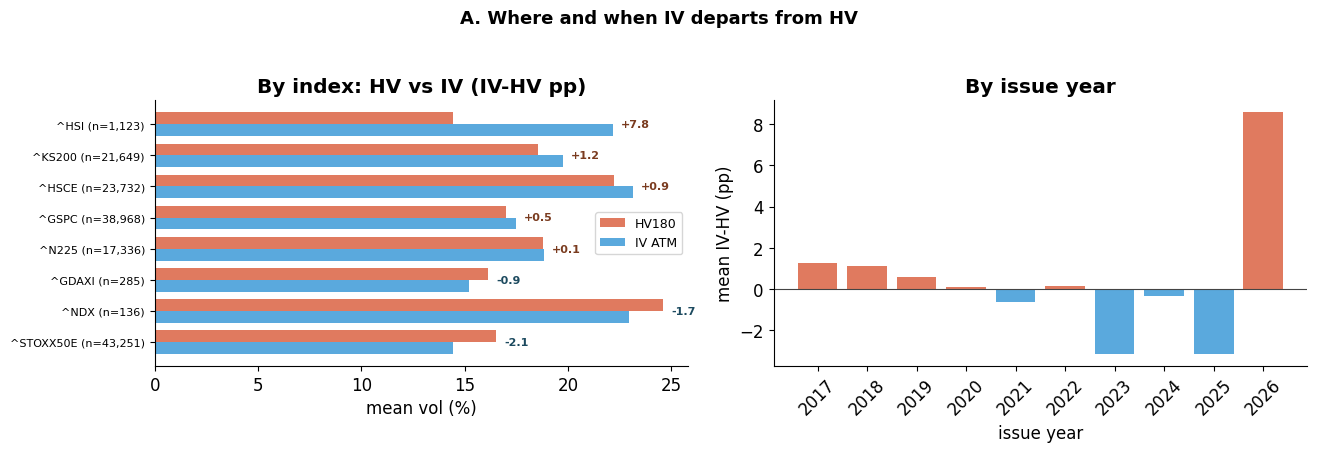

In [5]:
# 그림 A2: 지수별 · 연도별 부호편차
by = U.groupby("ticker").agg(n=("hv", "size"), hv=("hv", "mean"), iv=("iv", "mean")).assign(dev=lambda x: x.iv - x.hv).sort_values("dev")
yb = U.groupby("year").agg(dev=("dev", "mean")).reset_index()
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))
y = np.arange(len(by)); h = 0.38
ax[0].barh(y + h/2, by.hv * 100, h, color=C_HV, label="HV180"); ax[0].barh(y - h/2, by.iv * 100, h, color=C_IV, label="IV ATM")
ax[0].set_yticks(y); ax[0].set_yticklabels([f"{t} (n={int(n):,})" for t, n in zip(by.index, by.n)], fontsize=8)
for i, dv in enumerate(by.dev * 100):
    ax[0].text(max(by.hv.iloc[i], by.iv.iloc[i]) * 100 + .4, i, f"{dv:+.1f}", va="center", fontsize=8, fontweight="bold",
               color=(C_TERM if dv < 0 else "#7a3b1f"))
ax[0].set_xlabel("mean vol (%)"); ax[0].set_title("By index: HV vs IV (IV-HV pp)"); ax[0].legend(fontsize=9)
ax[1].bar(yb.year.astype(int).astype(str), yb.dev * 100, color=[C_IV if v < 0 else C_HV for v in yb.dev])
ax[1].axhline(0, color="#444", lw=.8); ax[1].set_ylabel("mean IV-HV (pp)"); ax[1].set_xlabel("issue year")
ax[1].set_title("By issue year"); ax[1].tick_params(axis="x", rotation=45)
fig.suptitle("A. Where and when IV departs from HV", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "iv_hv_by_index_year.png"); plt.show()

**A 요약**: 평균적으로 IV ≈ HV(부호편차 ≈ 0)이지만 상품마다 크게 흩어지고(|편차| ~4.7pp, std ~7.8pp) 상관 0.53뿐.
방향은 지수·연도별로 뒤집힘 → HV→IV 하드 대체는 체계적 재평가가 아니라 잡음 주입.

---
## B. base tenor 핀다운 + 평균회귀 → 만기매칭 IV

ATM IV 는 단일 tenor 한 점. (1) 그 tenor 가 며칠물인지 VIX 로 핀다운, (2) 시계열 평균회귀로 상품 만기에 맞는 vol 로 변환.

[base tenor] .SPX 16.61 | VIX(30d) 18.81 | VIX3M(93d) 20.75
  .SPX/VIX 0.885 (RMSE 5.33) | .SPX/VIX3M 0.792 (RMSE 6.78)
  -> .SPX 는 VIX(30d) 에 가장 근접하나 ~11% 낮음 = ATM 이 MFIV(VIX)보다 스큐프리미엄만큼 낮음 -> tenor≈30d ATM


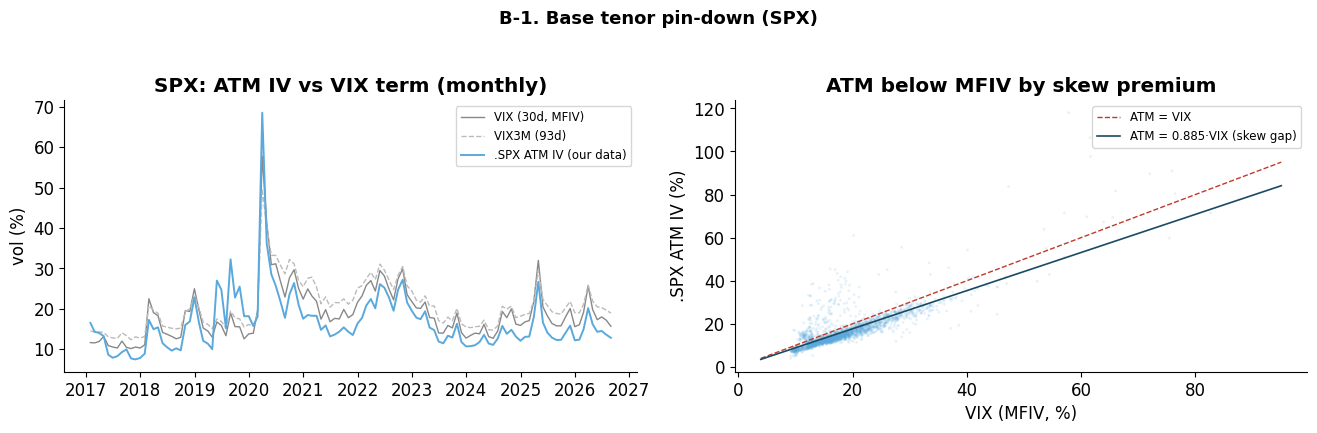

In [6]:
# B-1: base tenor — .SPX ATM 을 VIX(30d)·VIX3M(93d) 와 대조
spx = SER[".SPX"] * 100.0; vix, v3m = volidx("VIX"), volidx("VIX3M")
J = pd.concat({"spx": spx, "vix": vix, "vix3m": v3m}, axis=1).dropna()
print(f"[base tenor] .SPX {J.spx.mean():.2f} | VIX(30d) {J.vix.mean():.2f} | VIX3M(93d) {J.vix3m.mean():.2f}")
print(f"  .SPX/VIX {(J.spx/J.vix).mean():.3f} (RMSE {np.sqrt(((J.spx-J.vix)**2).mean()):.2f}) | "
      f".SPX/VIX3M {(J.spx/J.vix3m).mean():.3f} (RMSE {np.sqrt(((J.spx-J.vix3m)**2).mean()):.2f})")
print("  -> .SPX 는 VIX(30d) 에 가장 근접하나 ~11% 낮음 = ATM 이 MFIV(VIX)보다 스큐프리미엄만큼 낮음 -> tenor≈30d ATM")
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.4))
Jm = J.resample("ME").mean() if hasattr(J, "resample") else J
ax[0].plot(Jm.index, Jm.vix, color="#888", lw=1, label="VIX (30d, MFIV)")
ax[0].plot(Jm.index, Jm.vix3m, color="#bbb", lw=1, ls="--", label="VIX3M (93d)")
ax[0].plot(Jm.index, Jm.spx, color=C_IV, lw=1.4, label=".SPX ATM IV (our data)")
ax[0].set_ylabel("vol (%)"); ax[0].set_title("SPX: ATM IV vs VIX term (monthly)"); ax[0].legend(fontsize=8.5)
ax[1].scatter(J.vix, J.spx, s=4, alpha=.15, color=C_IV, edgecolors="none")
lim = [J[["spx", "vix"]].min().min(), J[["spx", "vix"]].quantile(.999).max()]
ax[1].plot(lim, lim, "--", color=C_ZERO, lw=1, label="ATM = VIX")
ax[1].plot(lim, [0.885 * x for x in lim], "-", color=C_TERM, lw=1.2, label="ATM = 0.885·VIX (skew gap)")
ax[1].set_xlabel("VIX (MFIV, %)"); ax[1].set_ylabel(".SPX ATM IV (%)"); ax[1].set_title("ATM below MFIV by skew premium"); ax[1].legend(fontsize=8.5)
fig.suptitle("B-1. Base tenor pin-down (SPX)", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "iv_tenor_pin.png"); plt.show()

In [7]:
# B-2: 평균회귀(κ,θ) — ATM IV 레벨 AR(1), θ=mean(IV^2)
PARAM = {}
print("[평균회귀]  index      b(AR1)  k/yr  half-life  long-run vol")
for udl, ric in IVMAP.items():
    s = SER.get(ric)
    if s is None or len(s) < 250: continue
    x = s.values; b, a = np.polyfit(x[:-1], x[1:], 1)
    k = (-np.log(b) / DTY) if (0 < b < 1) else 0.0; th = float(np.mean(x ** 2)); hl = (np.log(2) / k) if k > 0 else np.inf
    PARAM[udl] = (k, th)
    print(f"           {udl:10s} {b:.4f}  {k:5.1f}  {hl*12:5.2f}mo   {np.sqrt(th)*100:5.2f}%")

# 만기매칭 vol: 상품×자산
def term_sig(t, iv, H):
    k, th = PARAM.get(t, (0.0, iv ** 2)); fac = (1 - np.exp(-k * H)) / (k * H) if k > 0 else 1.0
    return float(np.sqrt(max(th + (iv ** 2 - th) * fac, 1e-6)))
rows = []
for r in df.itertuples(index=False):
    o = int(r.isu_ord); dt64 = np.datetime64(date.fromordinal(o)); H = float(r.tenor)
    for t in (r.udl1, r.udl2, r.udl3):
        iv = ivspot(t, dt64); hv = hv180(t, dt64)
        if np.isnan(iv) or np.isnan(hv) or t not in PARAM: continue
        rows.append((t, hv, iv, term_sig(t, iv, H)))
T = pd.DataFrame(rows, columns=["ticker", "hv", "spot", "term"])
print(f"\n[상품×자산 n={len(T):,}]  HV {T.hv.mean()*100:.2f}%  IV-spot {T.spot.mean()*100:.2f}% (vs HV {(T.spot-T.hv).mean()*100:+.2f}pp)  "
      f"IV-term {T.term.mean()*100:.2f}% (vs HV {(T.term-T.hv).mean()*100:+.2f}pp)")

[평균회귀]  index      b(AR1)  k/yr  half-life  long-run vol
           ^KS200     0.9237   20.0   0.42mo   26.47%
           ^GSPC      0.8937   28.3   0.29mo   18.69%
           ^HSCE      0.6147  122.6   0.07mo   26.85%
           ^HSI       0.6644  103.0   0.08mo   23.11%
           ^N225      0.9012   26.2   0.32mo   20.34%
           ^NDX       0.8428   43.1   0.19mo   24.29%
           ^GDAXI     0.9451   14.2   0.58mo   18.20%
           ^STOXX50E  0.9596   10.4   0.80mo   15.24%



[상품×자산 n=146,480]  HV 18.12%  IV-spot 18.02% (vs HV -0.09pp)  IV-term 20.37% (vs HV +2.25pp)


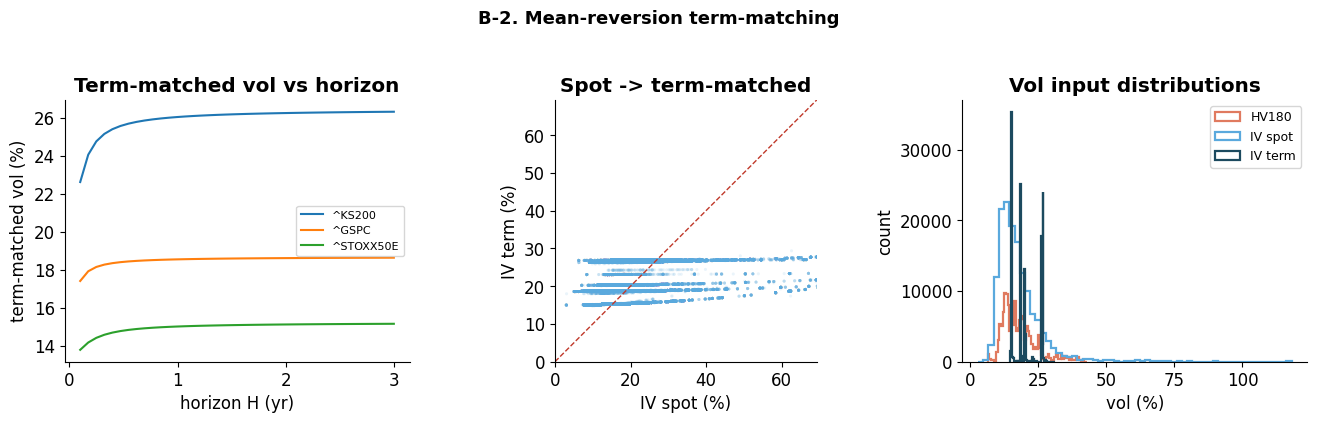

In [8]:
# 그림 B-2: term 구조 + spot vs term + 분포
fig, ax = plt.subplots(1, 3, figsize=(13.333, 4.3))
for udl in ["^KS200", "^GSPC", "^STOXX50E"]:
    if udl not in PARAM: continue
    k, th = PARAM[udl]; iv0 = np.median(SER[IVMAP[udl]].values)
    hh = np.linspace(0.1, 3, 40); fac = (1 - np.exp(-k * hh)) / (k * hh) if k > 0 else np.ones_like(hh)
    ax[0].plot(hh, np.sqrt(th + (iv0 ** 2 - th) * fac) * 100, label=f"{udl}")
ax[0].set_xlabel("horizon H (yr)"); ax[0].set_ylabel("term-matched vol (%)"); ax[0].set_title("Term-matched vol vs horizon"); ax[0].legend(fontsize=8)
lim = [0, max(T.spot.quantile(.995), T.term.quantile(.995)) * 100]
ax[1].scatter(T.spot * 100, T.term * 100, s=5, alpha=.12, color=C_IV, edgecolors="none"); ax[1].plot(lim, lim, "--", color=C_ZERO, lw=1)
ax[1].set_xlim(lim); ax[1].set_ylim(lim); ax[1].set_aspect("equal"); ax[1].set_xlabel("IV spot (%)"); ax[1].set_ylabel("IV term (%)"); ax[1].set_title("Spot -> term-matched")
for col, c, lab in [("hv", C_HV, "HV180"), ("spot", C_IV, "IV spot"), ("term", C_TERM, "IV term")]:
    ax[2].hist(T[col] * 100, bins=60, histtype="step", lw=1.6, color=c, label=lab)
ax[2].set_xlabel("vol (%)"); ax[2].set_ylabel("count"); ax[2].set_title("Vol input distributions"); ax[2].legend(fontsize=9)
fig.suptitle("B-2. Mean-reversion term-matching", fontsize=13, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "iv_term_matched.png"); plt.show()

**B 요약**: ATM IV ≈ 30d(VIX보다 스큐프리미엄만큼 낮음). vol 은 수주~1개월 평균회귀 → 3년 factor≈0.05 →
**만기매칭 vol ≈ 지수별 장기평균 √θ(위험중립), HV보다 +2.25pp 높음.** spot 잡음 제거 + 위험중립 레벨.

---
## C. MC 오차 검증 — HV vs spot-IV vs term-IV (핵심 결과)

같은 엔진·경로·NS할인·seed 로 **vol 입력만** 바꿔 전지수 worst-of 서브샘플의 `|fair−mc|` 비교.
(무거운 MC 는 `scratch/mc_term_test.py` 산출물 `result/statistics/mc_term_test.csv` 로드.)

In [9]:
p = STAT / "mc_term_test.csv"
if not p.exists():
    print("mc_term_test.csv 없음 — scratch/mc_term_test.py 실행 필요"); M = None
else:
    M = pd.read_csv(p)
    tab = []
    for k, lab in [("mc_hv", "HV180"), ("mc_spot", "IV spot ATM"), ("mc_term", "IV term-matched")]:
        e = (M.fair - M[k]); tab.append((lab, e.mean()*FACE, e.abs().mean()*FACE, np.sqrt((e**2).mean())*FACE))
    R = pd.DataFrame(tab, columns=["vol_input", "bias", "MAE", "RMSE"]).set_index("vol_input")
    base = R.loc["HV180", "MAE"]; R["MAE_vs_HV"] = R.MAE - base
    print(f"[전지수 worst-of n={len(M):,}, per 10,000 face]"); print(R.round(1).to_string())
    print(f"\n>>> IV term-matched: MAE {R.loc['IV term-matched','MAE']:.0f}원 (HV {base:.0f}원 대비 {R.loc['IV term-matched','MAE_vs_HV']:+.0f}원, "
          f"{R.loc['IV term-matched','MAE_vs_HV']/base*100:+.1f}%)")

[전지수 worst-of n=1,500, per 10,000 face]
                  bias    MAE   RMSE  MAE_vs_HV
vol_input                                      
HV180           -556.8  612.0  720.9        0.0
IV spot ATM     -501.6  680.4  837.2       68.4
IV term-matched -416.9  504.8  625.9     -107.1

>>> IV term-matched: MAE 505원 (HV 612원 대비 -107원, -17.5%)


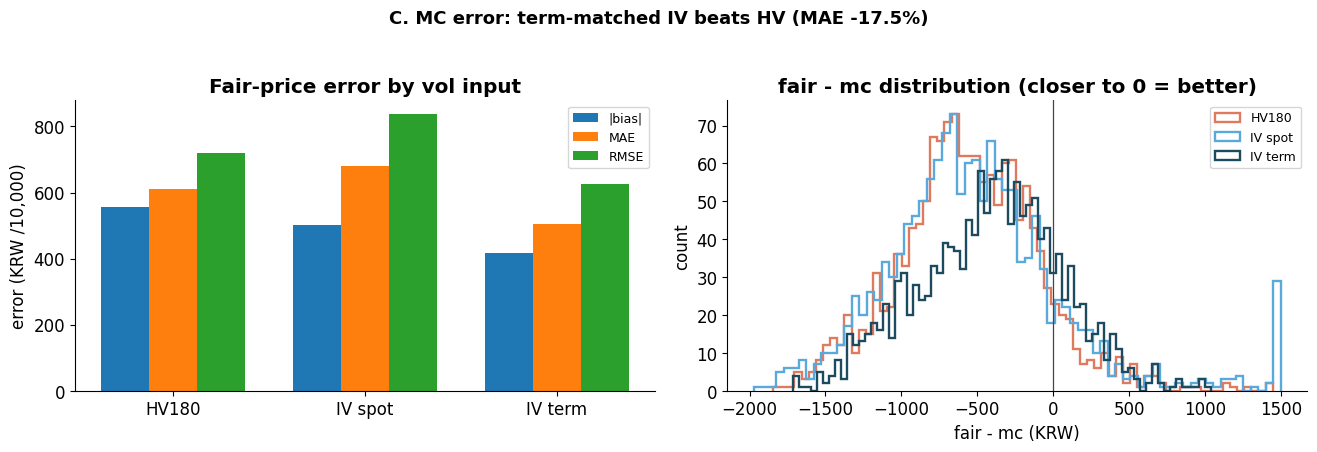

In [10]:
if M is not None:
    fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.6))
    labs = ["HV180", "IV spot", "IV term"]; keys = ["mc_hv", "mc_spot", "mc_term"]; cols = [C_HV, C_IV, C_TERM]
    bias = [abs((M.fair - M[k]).mean()) * FACE for k in keys]; mae = [(M.fair - M[k]).abs().mean() * FACE for k in keys]
    rmse = [np.sqrt(((M.fair - M[k]) ** 2).mean()) * FACE for k in keys]
    x = np.arange(3); w = 0.25
    for j, (vals, nm) in enumerate([(bias, "|bias|"), (mae, "MAE"), (rmse, "RMSE")]):
        ax[0].bar(x + (j - 1) * w, vals, w, label=nm)
    ax[0].set_xticks(x); ax[0].set_xticklabels(labs); ax[0].set_ylabel("error (KRW /10,000)")
    ax[0].set_title("Fair-price error by vol input"); ax[0].legend(fontsize=9)
    for i, k in enumerate(keys):
        ax[1].hist(((M.fair - M[k]) * FACE).clip(-2500, 1500), bins=70, histtype="step", lw=1.7, color=cols[i], label=labs[i])
    ax[1].axvline(0, color="#444", lw=.9); ax[1].set_xlabel("fair - mc (KRW)"); ax[1].set_ylabel("count")
    ax[1].set_title("fair - mc distribution (closer to 0 = better)"); ax[1].legend(fontsize=9)
    fig.suptitle("C. MC error: term-matched IV beats HV (MAE -17.5%)", fontsize=13, fontweight="bold")
    fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "iv_mc_error_compare.png"); plt.show()

**C 결과**: spot-IV 는 MAE 악화(+68원, 잡음), **term-IV 는 MAE 612→505원(−17.5%)·bias·RMSE 모두 개선.**
"발행시점 위험중립·만기적합 변동성" 이 후행 실현변동성(HV)보다 fair 에 가깝다는 확증.

---
## D. 스펙 방법론(VIX/Jiang-Tian) 검토 — vol 지수 확보 시도 + SPX 검증

스펙: Volatility Surface 에 VIX 방법론(Jiang & Tian 2005)으로 Volatility Term Structure 산출 → 해당 만기 vol 적용.
이는 **행사가×만기 서피스**가 필요(ATM 한 점으론 원리상 불가). 그 산출물인 vol 지수를 FRED·yfinance 에서 확보 시도.

In [11]:
# D-1: vol 지수 커버리지 (data/cache/volidx 에 받아둔 것)
MAP = {"^GSPC": ["VIX9D", "VIX", "VIX3M", "VIX6M"], "^NDX": ["VXN"], "^HSCE": ["VXFXI"],
       "^KS200": [], "^STOXX50E": [], "^HSI": [], "^N225": [], "^GDAXI": []}
TEN = {"VIX9D": 9, "VIX": 30, "VXN": 30, "VXFXI": 30, "VIX3M": 93, "VIX6M": 182}
print("[8개 기초자산 vol 지수 확보]")
for udl, idxs in MAP.items():
    have = [n for n in idxs if (CACHE / "volidx" / f"{n}.parquet").exists()]
    print(f"  {udl:11s} {have if have else '없음 -> ATM/HV 폴백'}")
print("  => VKOSPI·VSTOXX·VHSI·VNKY·VDAX 미확보(yfinance delisted) -> 북 전체 VIX-방법론 구현 불가")

# D-2: SPX 만은 실제 term structure 확보 -> 평균회귀 term-매칭 검증
vix = volidx("VIX"); v3m = volidx("VIX3M"); v6m = volidx("VIX6M"); v9d = volidx("VIX9D")
K = pd.concat({"v9": v9d, "v30": vix, "v93": v3m, "v182": v6m}, axis=1).dropna()
x = K.v30.values; b, a = np.polyfit(x[:-1], x[1:], 1); kap = -np.log(b) / DTY; thv = float(np.mean(x ** 2))
def predH(v30, H):
    f = (1 - np.exp(-kap * H)) / (kap * H); return np.sqrt(thv + (v30 ** 2 - thv) * f)
print(f"\n[SPX VIX30 평균회귀 검증] κ={kap:.2f}/yr 반감기 {np.log(2)/kap*12:.2f}mo")
for H, act, lab in [(93/365, K.v93, "VIX3M"), (182/365, K.v182, "VIX6M")]:
    pr = predH(K.v30.values, H)
    print(f"  {lab}: 실제 {act.mean():.2f} | VIX30 flat {K.v30.mean():.2f} | term-예측 {pr.mean():.2f} | corr {np.corrcoef(pr,act)[0,1]:.3f}")

[8개 기초자산 vol 지수 확보]
  ^GSPC       ['VIX9D', 'VIX', 'VIX3M', 'VIX6M']
  ^NDX        ['VXN']
  ^HSCE       ['VXFXI']
  ^KS200      없음 -> ATM/HV 폴백
  ^STOXX50E   없음 -> ATM/HV 폴백
  ^HSI        없음 -> ATM/HV 폴백
  ^N225       없음 -> ATM/HV 폴백
  ^GDAXI      없음 -> ATM/HV 폴백
  => VKOSPI·VSTOXX·VHSI·VNKY·VDAX 미확보(yfinance delisted) -> 북 전체 VIX-방법론 구현 불가

[SPX VIX30 평균회귀 검증] κ=9.60/yr 반감기 0.87mo
  VIX3M: 실제 20.07 | VIX30 flat 18.17 | term-예측 19.19 | corr 0.952
  VIX6M: 실제 21.52 | VIX30 flat 18.17 | term-예측 19.32 | corr 0.872


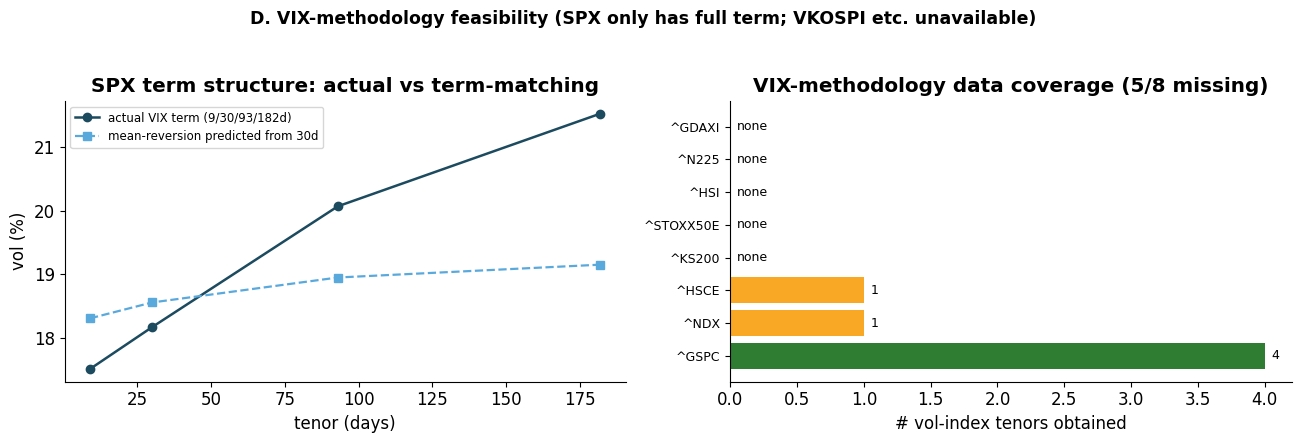

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(13.333, 4.5))
# (좌) SPX 평균 term structure: 실제 vs 30d 기반 평균회귀 예측
tens = np.array([9, 30, 93, 182]); actual = [K.v9.mean(), K.v30.mean(), K.v93.mean(), K.v182.mean()]
predc = [predH(K.v30.mean(), t / 365) for t in tens]
ax[0].plot(tens, actual, "o-", color=C_TERM, lw=1.8, label="actual VIX term (9/30/93/182d)")
ax[0].plot(tens, predc, "s--", color=C_IV, lw=1.6, label="mean-reversion predicted from 30d")
ax[0].set_xlabel("tenor (days)"); ax[0].set_ylabel("vol (%)"); ax[0].set_title("SPX term structure: actual vs term-matching"); ax[0].legend(fontsize=8.5)
# (우) 8개 기초자산 커버리지 막대
NEED = list(MAP.keys()); ncov = [len([n for n in MAP[u] if (CACHE / "volidx" / f"{n}.parquet").exists()]) for u in NEED]
cols = ["#2e7d32" if c > 1 else ("#f9a825" if c == 1 else "#c0392b") for c in ncov]
ax[1].barh(range(len(NEED)), ncov, color=cols); ax[1].set_yticks(range(len(NEED))); ax[1].set_yticklabels(NEED, fontsize=9)
ax[1].set_xlabel("# vol-index tenors obtained"); ax[1].set_title("VIX-methodology data coverage (5/8 missing)")
for i, c in enumerate(ncov): ax[1].text(c + .05, i, "none" if c == 0 else str(c), va="center", fontsize=9)
fig.suptitle("D. VIX-methodology feasibility (SPX only has full term; VKOSPI etc. unavailable)", fontsize=12.5, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95)); fig.savefig(IMG / "iv_volindex_validation.png"); plt.show()

**D 요약**: VIX-방법론(MFIV)은 행사가 서피스가 필요하고, 그 산출물인 vol 지수도 **VKOSPI·VSTOXX·VHSI·VNKY·VDAX 는 확보 불가**(yfinance delisted).
SPX 만 완전한 term(VIX9D/30/93/182) 확보 — 평균회귀 term-매칭이 실제 term 프리미엄의 **방향은 맞추나 크기는 과소추정**(corr 0.90~0.96). 스펙의 북 전체 구현은 데이터상 불가.

---
## E. 결론

1. **IV ≈ HV(평균) 이지만 상품별로 크게 흩어짐**(corr 0.53) → ATM spot 하드 대체는 잡음만 주입(MC MAE +68원).
2. **만기매칭 IV(≈위험중립 장기평균, HV+2.25pp)** 는 HV 대비 공정가 오차를 줄임 — **MC MAE 612→505원(−17.5%)**, bias·RMSE 동반 개선. 발행시점 위험중립·만기적합 변동성이 후행 실현변동성보다 fair 에 가깝다.
3. **스펙(VIX/Jiang-Tian) 은 데이터상 불가**: MFIV 는 행사가 서피스가 필요하고, 대체 산출물인 vol 지수도 핵심(VKOSPI 등) 미확보. SPX 만 부분 검증 가능.
4. **잔여 스큐 위험(KI 하방)** 은 ATM 계열로는 미반영 — 필요 시 레버리지 ρ 확률변동성 MC(별도 엔진)로만 접근 가능.
5. **채택 권고**: term-매칭 ATM IV 를 발행시점 MC 변동성 입력으로. 상관은 스펙대로 180영업일 역사상관.